In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 

In [5]:
import pandas as pd 

df = pd.read_csv(r"C:\Users\manas\Downloads\ALONE\New folder\new\PAIMANA\ml-pipeline\data\processed\merged_projects.csv")

df.head()

C:\Users\manas\AppData\Local\Temp\ipykernel_6484\2729426654.py:3: DtypeWarning: Columns (0,6,25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\manas\Downloads\ALONE\New folder\new\PAIMANA\ml-pipeline\data\processed\merged_projects.csv")


,project_code,project_name,agency,state,date_of_approval,start_date,actual_doc,target_doc,revised_doc,original_cost_cr,...,cost_overrun_pct,delay_actual_days,delay_proxy_days,expenditure_to_original_cost_ratio,expenditure_to_revised_cost_ratio,expenditure_exceeds_revised_cost,expenditure_progress_mismatch,high_spend_low_progress_flag,negative_expenditure_flag,negative_cost_overrun_flag
0,612786,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],Andhra Pradesh,2023-03-01,2024-01-01,NaN,2026-01-01,2026-03-01,265.91,...,0.0,NaN,59 days,0.288255,0.288255,False,-0.131745,False,False,False
1,701107,Construction of New Integrated Terminal Buildi...,Airport Authority of India [AAI],Andhra Pradesh,2020-06-01,2020-09-01,NaN,2022-09-01,2026-03-01,611.80,...,0.0,NaN,1277 days,0.855083,0.855083,False,-0.004917,False,False,False
2,701121,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],Andhra Pradesh,2022-12-01,2023-08-01,NaN,2025-08-01,2026-03-01,347.15,...,0.0,NaN,212 days,0.315771,0.315771,False,-0.324229,False,False,False
3,706724,Guwahati Airport New Integrated Terminal Build...,Adani Airport Holdings Limited,Assam,2016-12-01,2018-03-01,NaN,2025-03-01,2025-11-01,1712.00,...,0.0,NaN,245 days,1.434620,1.434620,True,0.494620,False,False,False
4,612183,Development of New Civil Enclave at Bihta,Airport Authority of India [AAI],Bihar,2024-08-01,2025-03-01,NaN,2027-09-01,NaN,1413.00,...,0.0,NaN,NaN,0.000000,0.000000,False,-0.010000,False,False,False


In [6]:
df.shape

(18601, 34)

In [7]:
df.info()
df.columns
df.describe(include="all")
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18601 entries, 0 to 18600
Data columns (total 34 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   project_code                         18601 non-null  object 
 1   project_name                         18601 non-null  object 
 2   agency                               18601 non-null  object 
 3   state                                18596 non-null  object 
 4   date_of_approval                     17171 non-null  object 
 5   start_date                           17737 non-null  object 
 6   actual_doc                           107 non-null    object 
 7   target_doc                           18001 non-null  object 
 8   revised_doc                          12914 non-null  object 
 9   original_cost_cr                     18601 non-null  float64
 10  revised_cost_cr                      18383 non-null  float64
 11  cumulative expenditure in rs

project_code                               0
project_name                               0
agency                                     0
state                                      5
date_of_approval                        1430
start_date                               864
actual_doc                             18494
target_doc                               600
revised_doc                             5687
original_cost_cr                           0
revised_cost_cr                          218
cumulative expenditure in rs. crore        1
physical progress (in percentage)          0
ministry                                 129
sector                                     0
status                                     0
date_of_approval_is_missing                0
start_date_is_missing                      0
actual_doc_is_missing                      0
target_doc_is_missing                      0
revised_doc_is_missing                     0
revised_cost_cr_is_missing                 0
ministry_i

In [9]:
df.duplicated().sum()

np.int64(2784)

In [10]:
df[df.duplicated(keep=False)].head(20)

,project_code,project_name,agency,state,date_of_approval,start_date,actual_doc,target_doc,revised_doc,original_cost_cr,...,cost_overrun_pct,delay_actual_days,delay_proxy_days,expenditure_to_original_cost_ratio,expenditure_to_revised_cost_ratio,expenditure_exceeds_revised_cost,expenditure_progress_mismatch,high_spend_low_progress_flag,negative_expenditure_flag,negative_cost_overrun_flag
4,612183,Development of New Civil Enclave at Bihta,Airport Authority of India [AAI],Bihar,2024-08-01,2025-03-01,NaN,2027-09-01,NaN,1413.00,...,0.000000,NaN,NaN,0.000000,0.000000,False,-0.010000,False,False,False
26,615821,TIRAP OCP,MIS MoCoal Integration Logins,Assam,2022-11-01,2022-11-01,NaN,2030-11-01,NaN,289.46,...,0.000000,NaN,NaN,0.364852,0.364852,False,0.334852,False,False,False
32,613798,AMERA OC RCE [1.0 MTY],South Eastern Coalfields Limited [SECL],Chhattisgarh,2015-02-01,2015-02-01,NaN,2026-03-01,NaN,335.97,...,0.000000,NaN,NaN,0.262642,0.262642,False,-0.157358,False,False,False
33,613799,AMGAON OC RCE [1.0 MTY],South Eastern Coalfields Limited [SECL],Chhattisgarh,2015-07-01,2015-07-01,NaN,2026-03-01,NaN,316.11,...,0.000000,NaN,NaN,0.597007,0.597007,False,-0.182993,False,False,False
34,613800,JAGANNATHPUR OC RCE PROJECT,South Eastern Coalfields Limited [SECL],Chhattisgarh,2016-07-01,2016-07-01,NaN,2025-03-01,2026-03-01,459.49,...,0.000000,NaN,365 days,0.597075,0.597075,False,-0.362925,False,False,False
36,615191,KATKONA RO UG MINE,South Eastern Coalfields Limited [SECL],Chhattisgarh,2023-01-01,2023-01-01,NaN,2029-03-01,NaN,329.21,...,0.000000,NaN,NaN,0.186325,0.186325,False,0.166325,False,False,False
37,616234,PELMA OC MDO,South Eastern Coalfields Limited [SECL],Chhattisgarh,2022-10-01,2022-10-01,NaN,2033-03-01,NaN,1725.04,...,0.000000,NaN,NaN,0.009078,0.009078,False,-0.390922,False,False,False
39,617288,MANIKPUR OC EXPANSION PROJECT,South Eastern Coalfields Limited [SECL],Chhattisgarh,2025-01-01,2025-01-01,NaN,2029-03-01,NaN,382.61,...,0.000000,NaN,NaN,0.295418,0.295418,False,0.085418,False,False,False
41,400073,KONAR EXPANSION OCP,Ministry of Coal,Jharkhand,2022-01-01,2022-01-01,NaN,2032-03-01,NaN,799.34,...,0.000000,NaN,NaN,0.537506,0.537506,False,0.087506,False,False,False
42,400074,KARO EXPANSION OCP,Ministry of Coal,Jharkhand,2022-01-01,2022-01-01,NaN,2029-03-01,NaN,908.47,...,0.000000,NaN,NaN,0.296388,0.296388,False,0.076388,False,False,False


In [11]:
df[df.duplicated(keep=False)][["project_code" ,"project_name" ,"status"]].head(10)

,project_code,project_name,status
4,612183,Development of New Civil Enclave at Bihta,Ongoing
26,615821,TIRAP OCP,Ongoing
32,613798,AMERA OC RCE [1.0 MTY],Ongoing
33,613799,AMGAON OC RCE [1.0 MTY],Ongoing
34,613800,JAGANNATHPUR OC RCE PROJECT,Ongoing
36,615191,KATKONA RO UG MINE,Ongoing
37,616234,PELMA OC MDO,Ongoing
39,617288,MANIKPUR OC EXPANSION PROJECT,Ongoing
41,400073,KONAR EXPANSION OCP,Ongoing
42,400074,KARO EXPANSION OCP,Ongoing


In [12]:
df[df.duplicated()].head(10)

,project_code,project_name,agency,state,date_of_approval,start_date,actual_doc,target_doc,revised_doc,original_cost_cr,...,cost_overrun_pct,delay_actual_days,delay_proxy_days,expenditure_to_original_cost_ratio,expenditure_to_revised_cost_ratio,expenditure_exceeds_revised_cost,expenditure_progress_mismatch,high_spend_low_progress_flag,negative_expenditure_flag,negative_cost_overrun_flag
827,612183,Development of New Civil Enclave at Bihta,Airport Authority of India [AAI],Bihar,2024-08-01,2025-03-01,NaN,2027-09-01,NaN,1413.00,...,0.000000,NaN,NaN,0.000000,0.000000,False,-0.010000,False,False,False
858,613798,AMERA OC RCE [1.0 MTY],South Eastern Coalfields Limited [SECL],Chhattisgarh,2015-02-01,2015-02-01,NaN,2026-03-01,NaN,335.97,...,0.000000,NaN,NaN,0.262642,0.262642,False,-0.157358,False,False,False
860,613800,JAGANNATHPUR OC RCE PROJECT,South Eastern Coalfields Limited [SECL],Chhattisgarh,2016-07-01,2016-07-01,NaN,2025-03-01,2026-03-01,459.49,...,0.000000,NaN,365 days,0.597075,0.597075,False,-0.362925,False,False,False
863,616234,PELMA OC MDO,South Eastern Coalfields Limited [SECL],Chhattisgarh,2022-10-01,2022-10-01,NaN,2033-03-01,NaN,1725.04,...,0.000000,NaN,NaN,0.009078,0.009078,False,-0.390922,False,False,False
872,400139,KOTRE BASANTPUR PACHMO OCP,Ministry of Coal,Jharkhand,2020-08-01,2020-08-01,NaN,2032-03-01,NaN,861.06,...,-0.273686,NaN,NaN,0.529522,0.729053,False,0.109522,False,False,True
875,400151,NORTH URIMARI EXPANSION OCP,Ministry of Coal,Jharkhand,2021-07-01,2021-07-01,NaN,2029-03-01,NaN,778.80,...,0.000000,NaN,NaN,0.893747,0.893747,False,0.223747,False,False,False
877,400154,EPR PUNDI OCP,Ministry of Coal,Jharkhand,2020-11-01,2020-11-01,NaN,2027-03-01,NaN,713.35,...,0.000000,NaN,NaN,0.331646,0.331646,False,0.231646,False,False,False
882,400352,JHARKHAND-LAIYO OCP,Ministry of Coal,Jharkhand,2020-08-01,2020-08-01,NaN,2031-03-01,NaN,764.57,...,0.000000,NaN,NaN,0.190709,0.190709,False,-0.099291,False,False,False
886,613808,MURAIDIH UG PROJECT,Ministry of Coal,Jharkhand,2011-02-01,2011-02-01,NaN,2014-04-01,2026-12-01,339.87,...,0.000000,NaN,4627 days,0.561980,0.561980,False,-0.138020,False,False,False
887,615349,TAPIN SOUTH EXPN,Ministry of Coal,Jharkhand,2020-11-01,2020-11-01,NaN,2028-03-01,NaN,230.41,...,0.000000,NaN,NaN,0.095569,0.095569,False,-0.104431,False,False,False


In [13]:
df[df.duplicated()].shape

(2784, 34)

In [15]:
df[df.duplicated()].status.value_counts()

status
Ongoing    2784
Name: count, dtype: int64

In [16]:
df[df.duplicated()][["project_code","project_name","date_of_approval" ,"start_date" ,"target_doc","status"]].head(20)

,project_code,project_name,date_of_approval,start_date,target_doc,status
827,612183,Development of New Civil Enclave at Bihta,2024-08-01,2025-03-01,2027-09-01,Ongoing
858,613798,AMERA OC RCE [1.0 MTY],2015-02-01,2015-02-01,2026-03-01,Ongoing
860,613800,JAGANNATHPUR OC RCE PROJECT,2016-07-01,2016-07-01,2025-03-01,Ongoing
863,616234,PELMA OC MDO,2022-10-01,2022-10-01,2033-03-01,Ongoing
872,400139,KOTRE BASANTPUR PACHMO OCP,2020-08-01,2020-08-01,2032-03-01,Ongoing
875,400151,NORTH URIMARI EXPANSION OCP,2021-07-01,2021-07-01,2029-03-01,Ongoing
877,400154,EPR PUNDI OCP,2020-11-01,2020-11-01,2027-03-01,Ongoing
882,400352,JHARKHAND-LAIYO OCP,2020-08-01,2020-08-01,2031-03-01,Ongoing
886,613808,MURAIDIH UG PROJECT,2011-02-01,2011-02-01,2014-04-01,Ongoing
887,615349,TAPIN SOUTH EXPN,2020-11-01,2020-11-01,2028-03-01,Ongoing


In [17]:
df.duplicated().sum()

np.int64(2784)

In [18]:
df.shape

(18601, 34)

In [19]:
date_columns = [
    "date_of_approval",
    "start_date",
    "target_doc",
    "revised_doc",
    "actual_doc"
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors="coerce")

In [20]:
df[date_columns].dtypes

date_of_approval    datetime64[ns]
start_date          datetime64[ns]
target_doc          datetime64[ns]
revised_doc         datetime64[ns]
actual_doc          datetime64[ns]
dtype: object

In [22]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

actual_doc                             18494
delay_actual_days                      18494
revised_doc                             5687
delay_proxy_days                        5687
date_of_approval                        1430
start_date                               864
target_doc                               600
revised_cost_cr                          218
cost_overrun_abs_cr                      218
cost_overrun_pct                         218
expenditure_to_revised_cost_ratio        218
ministry                                 129
state                                      5
cumulative expenditure in rs. crore        1
expenditure_to_original_cost_ratio         1
expenditure_progress_mismatch              1
dtype: int64

In [23]:
df.groupby("status")[[
    "date_of_approval",
    "start_date",
    "target_doc",
    "revised_doc",
    "actual_doc",
    "revised_cost_cr",
    "ministry"
]].apply(lambda x: x.isnull().sum())

,date_of_approval,start_date,target_doc,revised_doc,actual_doc,revised_cost_cr,ministry
status,,,,,,,
Completed,118,116,116,119,268,205,116
Frozen or Deleted,0,13,13,13,13,13,13
Ongoing,1312,735,471,5555,18213,0,0


In [24]:
df[df["state"].isnull()][
    ["project_code", "project_name", "agency", "state"]
]

,project_code,project_name,agency,state
1263,617338,Stamp Charge Battery No.12 Battery Proper at I...,Steel Authority of India Limited [SAIL],NaN
1778,617272,Implementation of LILO of both circuits of 400...,Power Grid Corporation of India Limited [POWER...,NaN
3781,612885,Construction and Developement of National Inst...,"National Institute of Technology, Meghalaya",NaN
8646,617338,Stamp Charge Battery No.12 Battery Proper at I...,Steel Authority of India Limited [SAIL],NaN
13938,612885,Construction and Developement of National Inst...,"National Institute of Technology, Meghalaya",NaN


In [25]:
df[df["cumulative expenditure in rs. crore"] < 0][
    ["project_code", "project_name",
     "cumulative expenditure in rs. crore", "status"]
]

,project_code,project_name,cumulative expenditure in rs. crore,status
4414,618930,4L PS from Ch. 94.030 in Jabugam Village to Ch...,-4.88,Ongoing
4844,619113,4L of Padalur - Trichy section from km. 285.00...,-0.08,Ongoing


In [ ]:
# Data quality issue:
# 2 Ongoing projects have negative cumulative expenditure.
# Values: -4.88 and -0.08 crore.
# As per data dictionary, these are data errors.
# Correction requires source lookup; no automatic imputation applied.

In [26]:
df[df["revised_cost_cr"] < df["original_cost_cr"]][
    ["project_code", "project_name",
     "original_cost_cr", "revised_cost_cr",
     "cost_overrun_abs_cr", "cost_overrun_pct"]
].head(10)

,project_code,project_name,original_cost_cr,revised_cost_cr,cost_overrun_abs_cr,cost_overrun_pct
45,400139,KOTRE BASANTPUR PACHMO OCP,861.06,625.40,-235.66,-0.273686
110,400185,GOPALJI KANIHA OCP [10 TO 30 M,8416.19,6107.87,-2308.32,-0.274271
130,400181,NAKRAKONDA KUMARDIH- B OCP,502.68,502.67,-0.01,-0.000020
131,400182,SIDULI [OC & UG],535.18,535.17,-0.01,-0.000019
132,400186,TILABONI UG,749.08,749.07,-0.01,-0.000013
230,611659,Transmission system strengthening scheme for e...,1433.28,1433.00,-0.28,-0.000195
253,702630,Surat Metro Rail Project,12020.32,12020.30,-0.02,-0.000002
324,610315,IISER BERHAMPUR,1229.32,843.09,-386.23,-0.314182
325,612877,Establishment of NIT Puducherry Permanent Camp...,618.34,544.34,-74.00,-0.119675
329,612883,Establishment of Permanent Campus of NIT SIkki...,685.76,610.76,-75.00,-0.109368


In [27]:
# Data quality observation:
# 2,549 projects have revised_cost_cr < original_cost_cr.
# Negative cost overrun is not necessarily an error and may represent
# de-scoping or cost savings. Values are preserved as-is.

In [28]:
target_columns = [
    "cost_overrun_abs_cr",
    "cost_overrun_pct",
    "delay_actual_days",
    "delay_proxy_days"
]

df[target_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18601 entries, 0 to 18600
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cost_overrun_abs_cr  18383 non-null  float64
 1   cost_overrun_pct     18383 non-null  float64
 2   delay_actual_days    107 non-null    object 
 3   delay_proxy_days     12914 non-null  object 
dtypes: float64(2), object(2)
memory usage: 581.4+ KB


In [29]:
df[target_columns].notnull().sum()

cost_overrun_abs_cr    18383
cost_overrun_pct       18383
delay_actual_days        107
delay_proxy_days       12914
dtype: int64

In [30]:
target_columns = [
    "cost_overrun_abs_cr",
    "cost_overrun_pct",
    "delay_actual_days",
    "delay_proxy_days"
]

df[target_columns].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18601 entries, 0 to 18600
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   cost_overrun_abs_cr  18383 non-null  float64
 1   cost_overrun_pct     18383 non-null  float64
 2   delay_actual_days    107 non-null    object 
 3   delay_proxy_days     12914 non-null  object 
dtypes: float64(2), object(2)
memory usage: 581.4+ KB


In [31]:
df[target_columns].notnull().sum()

cost_overrun_abs_cr    18383
cost_overrun_pct       18383
delay_actual_days        107
delay_proxy_days       12914
dtype: int64

In [32]:
leakage_columns = [
    "revised_cost_cr",
    "revised_doc",
    "actual_doc",
    "cumulative expenditure in rs. crore"
]

df[leakage_columns].head()

,revised_cost_cr,revised_doc,actual_doc,cumulative expenditure in rs. crore
0,265.91,2026-03-01,NaT,76.65
1,611.80,2026-03-01,NaT,523.14
2,347.15,2026-03-01,NaT,109.62
3,1712.00,2025-11-01,NaT,2456.07
4,1413.00,NaT,NaT,0.00


In [33]:
df[leakage_columns].isnull().sum()

revised_cost_cr                          218
revised_doc                             5687
actual_doc                             18494
cumulative expenditure in rs. crore        1
dtype: int64

In [34]:
leakage_columns = [
    "revised_cost_cr",
    "revised_doc",
    "actual_doc",
    "cumulative expenditure in rs. crore"
]


In [35]:
df[leakage_columns].isnull().sum()

revised_cost_cr                          218
revised_doc                             5687
actual_doc                             18494
cumulative expenditure in rs. crore        1
dtype: int64

In [36]:
df.columns.tolist()

['project_code',
 'project_name',
 'agency',
 'state',
 'date_of_approval',
 'start_date',
 'actual_doc',
 'target_doc',
 'revised_doc',
 'original_cost_cr',
 'revised_cost_cr',
 'cumulative expenditure in rs. crore',
 'physical progress (in percentage)',
 'ministry',
 'sector',
 'status',
 'date_of_approval_is_missing',
 'start_date_is_missing',
 'actual_doc_is_missing',
 'target_doc_is_missing',
 'revised_doc_is_missing',
 'revised_cost_cr_is_missing',
 'ministry_is_missing',
 'cost_overrun_abs_cr',
 'cost_overrun_pct',
 'delay_actual_days',
 'delay_proxy_days',
 'expenditure_to_original_cost_ratio',
 'expenditure_to_revised_cost_ratio',
 'expenditure_exceeds_revised_cost',
 'expenditure_progress_mismatch',
 'high_spend_low_progress_flag',
 'negative_expenditure_flag',
 'negative_cost_overrun_flag']

In [37]:
df.dtypes

project_code                                   object
project_name                                   object
agency                                         object
state                                          object
date_of_approval                       datetime64[ns]
start_date                             datetime64[ns]
actual_doc                             datetime64[ns]
target_doc                             datetime64[ns]
revised_doc                            datetime64[ns]
original_cost_cr                              float64
revised_cost_cr                               float64
cumulative expenditure in rs. crore           float64
physical progress (in percentage)             float64
ministry                                       object
sector                                         object
status                                         object
date_of_approval_is_missing                     int64
start_date_is_missing                           int64
actual_doc_is_missing       

In [38]:
df["delay_actual_days"].value_counts(dropna=False).head(20)

delay_actual_days
NaN           18494
334 days          4
365 days          4
-28 days          4
306 days          3
455 days          3
-1492 days        2
487 days          2
762 days          2
-59 days          2
181 days          2
1188 days         2
669 days          2
0 days            2
731 days          2
792 days          2
1004 days         2
1461 days         2
884 days          2
-212 days         2
Name: count, dtype: int64

In [39]:
df["delay_proxy_days"].value_counts(dropna=False).head(20)

delay_proxy_days
NaN          5687
0 days       2531
365 days      465
730 days      285
426 days      182
396 days      178
1096 days     172
304 days      168
243 days      159
334 days      155
275 days      145
1461 days     141
212 days      139
2282 days     130
273 days      130
457 days      110
518 days      103
214 days      101
92 days        95
151 days       95
Name: count, dtype: int64

In [40]:
df["delay_actual_days"] = (
    df["delay_actual_days"]
    .str.replace(" days", "", regex=False)
    .astype(float)
)

In [41]:
df["delay_actual_days"].dtype

dtype('float64')

In [42]:
df["delay_proxy_days"] = (
    df["delay_proxy_days"]
    .str.replace(" days", "", regex=False)
    .astype(float)
)

In [45]:
df[["delay_actual_days","delay_proxy_days"]].dtypes

delay_actual_days    float64
delay_proxy_days     float64
dtype: object

In [46]:
numeric_columns = [
    "original_cost_cr",
    "revised_cost_cr",
    "cumulative expenditure in rs. crore",
    "physical progress (in percentage)",
    "cost_overrun_abs_cr",
    "cost_overrun_pct",
    "delay_actual_days",
    "delay_proxy_days"
]

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
original_cost_cr,18601.0,2129.149353,5806.486297,68.000000,354.2100,790.780,1652.400000,150000.000000
revised_cost_cr,18383.0,2504.684878,8272.497639,0.100000,359.5600,819.000,1834.810000,188000.000000
cumulative expenditure in rs. crore,18600.0,1289.095921,5594.620708,-4.880000,57.1725,260.295,792.462500,124623.000000
physical progress (in percentage),18601.0,57.710019,35.369924,0.000000,23.2400,66.000,91.340000,100.000000
cost_overrun_abs_cr,18383.0,361.675474,4095.496011,-48400.000000,0.0000,0.000,5.880000,126891.000000
cost_overrun_pct,18383.0,0.112244,0.590837,-0.999581,0.0000,0.000,0.006809,19.210121
delay_actual_days,107.0,692.943925,1288.635726,-3135.000000,213.0000,456.000,1006.000000,8827.000000
delay_proxy_days,12914.0,700.730060,965.309668,-10837.000000,92.0000,426.000,974.000000,9131.000000


In [47]:
missing_flag_columns = [
    "date_of_approval_is_missing",
    "start_date_is_missing",
    "actual_doc_is_missing",
    "target_doc_is_missing",
    "revised_doc_is_missing",
    "revised_cost_cr_is_missing",
    "ministry_is_missing"
]

df[missing_flag_columns].sum()

date_of_approval_is_missing     1430
start_date_is_missing            864
actual_doc_is_missing          18494
target_doc_is_missing            600
revised_doc_is_missing          5687
revised_cost_cr_is_missing       218
ministry_is_missing              129
dtype: int64

In [48]:
quality_flag_columns = [
    "negative_expenditure_flag",
    "negative_cost_overrun_flag",
    "expenditure_exceeds_revised_cost",
    "high_spend_low_progress_flag"
]

df[quality_flag_columns].sum()

negative_expenditure_flag              2
negative_cost_overrun_flag          2549
expenditure_exceeds_revised_cost     759
high_spend_low_progress_flag          39
dtype: int64

In [49]:
quality_flag_columns = [
    "negative_expenditure_flag",
    "negative_cost_overrun_flag",
    "expenditure_exceeds_revised_cost",
    "high_spend_low_progress_flag"
]

df[quality_flag_columns].sum()

negative_expenditure_flag              2
negative_cost_overrun_flag          2549
expenditure_exceeds_revised_cost     759
high_spend_low_progress_flag          39
dtype: int64

In [50]:
quality_flag_columns = [
    "negative_expenditure_flag",
    "negative_cost_overrun_flag",
    "expenditure_exceeds_revised_cost",
    "high_spend_low_progress_flag"
]

df[quality_flag_columns].sum()

negative_expenditure_flag              2
negative_cost_overrun_flag          2549
expenditure_exceeds_revised_cost     759
high_spend_low_progress_flag          39
dtype: int64

In [51]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("\nData types:")
print(df.dtypes)

Rows: 18601
Columns: 34

Data types:
project_code                                   object
project_name                                   object
agency                                         object
state                                          object
date_of_approval                       datetime64[ns]
start_date                             datetime64[ns]
actual_doc                             datetime64[ns]
target_doc                             datetime64[ns]
revised_doc                            datetime64[ns]
original_cost_cr                              float64
revised_cost_cr                               float64
cumulative expenditure in rs. crore           float64
physical progress (in percentage)             float64
ministry                                       object
sector                                         object
status                                         object
date_of_approval_is_missing                     int64
start_date_is_missing                        

In [52]:
df.head()

,project_code,project_name,agency,state,date_of_approval,start_date,actual_doc,target_doc,revised_doc,original_cost_cr,...,cost_overrun_pct,delay_actual_days,delay_proxy_days,expenditure_to_original_cost_ratio,expenditure_to_revised_cost_ratio,expenditure_exceeds_revised_cost,expenditure_progress_mismatch,high_spend_low_progress_flag,negative_expenditure_flag,negative_cost_overrun_flag
0,612786,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],Andhra Pradesh,2023-03-01,2024-01-01,NaT,2026-01-01,2026-03-01,265.91,...,0.0,NaN,59.0,0.288255,0.288255,False,-0.131745,False,False,False
1,701107,Construction of New Integrated Terminal Buildi...,Airport Authority of India [AAI],Andhra Pradesh,2020-06-01,2020-09-01,NaT,2022-09-01,2026-03-01,611.80,...,0.0,NaN,1277.0,0.855083,0.855083,False,-0.004917,False,False,False
2,701121,Construction of New Domestic Terminal Building...,Airport Authority of India [AAI],Andhra Pradesh,2022-12-01,2023-08-01,NaT,2025-08-01,2026-03-01,347.15,...,0.0,NaN,212.0,0.315771,0.315771,False,-0.324229,False,False,False
3,706724,Guwahati Airport New Integrated Terminal Build...,Adani Airport Holdings Limited,Assam,2016-12-01,2018-03-01,NaT,2025-03-01,2025-11-01,1712.00,...,0.0,NaN,245.0,1.434620,1.434620,True,0.494620,False,False,False
4,612183,Development of New Civil Enclave at Bihta,Airport Authority of India [AAI],Bihar,2024-08-01,2025-03-01,NaT,2027-09-01,NaT,1413.00,...,0.0,NaN,NaN,0.000000,0.000000,False,-0.010000,False,False,False


In [54]:
output_path = "../data/processed/merged_projects_cleaned.csv"

df.to_csv(output_path, index=False)

print("Cleaned dataset saved successfully!")
print(output_path)

Cleaned dataset saved successfully!
../data/processed/merged_projects_cleaned.csv


In [55]:
import os
print(os.path.exists(output_path))

True


In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Scikit-learn imported successfully!")

Scikit-learn imported successfully!


In [57]:
# Target
target = "delay_proxy_days"

# Columns that must NOT be used as features
excluded_columns = [
    "delay_proxy_days",
    "delay_actual_days",
    "revised_doc",
    "actual_doc",
    "revised_cost_cr",
    "cumulative expenditure in rs. crore",
    "cost_overrun_abs_cr",
    "cost_overrun_pct",
    "status",
    "project_code",
    "project_name"
]

# Features
X = df.drop(columns=excluded_columns)

# Target
y = df[target]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (18601, 23)
Target shape: (18601,)


In [58]:
categorical_columns = X.select_dtypes(include=["object"]).columns.tolist()

print("Categorical columns:")
print(categorical_columns)

Categorical columns:
['agency', 'state', 'ministry', 'sector']


In [59]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Numerical columns
numerical_columns = X.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()

# Preprocessing for categorical columns
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Preprocessing for numerical columns
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_columns),
        ("cat", categorical_transformer, categorical_columns)
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (14880, 23)
X_test: (3721, 23)
y_train: (14880,)
y_test: (3721,)


In [61]:
# Create Random Forest pipeline
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

ValueError: Input y contains NaN.

In [62]:
# Keep only rows where the target is available
model_data = df[df["delay_proxy_days"].notna()].copy()

# Features and target
X = model_data.drop(columns=excluded_columns)
y = model_data["delay_proxy_days"]

print("Model data shape:", model_data.shape)
print("Target missing:", y.isna().sum())

Model data shape: (12914, 34)
Target missing: 0


In [63]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (10331, 23)
X_test: (2583, 23)


In [64]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [65]:
# Make predictions on test data
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("Model Performance")
print("------------------")
print("MAE :", mae)
print("RMSE:", rmse)
print("R²  :", r2)

Model Performance
------------------
MAE : 136.56273357887764
RMSE: 346.8810724215211
R²  : 0.8807339419385748


In [66]:
results = pd.DataFrame({
    "Actual Delay (days)": y_test.values,
    "Predicted Delay (days)": y_pred
})

results.head(10)

,Actual Delay (days),Predicted Delay (days)
0,0.0,11.880
1,2648.0,2025.130
2,2101.0,2101.000
3,-184.0,-146.310
4,183.0,161.260
5,0.0,227.130
6,334.0,305.560
7,0.0,-3.640
8,426.0,189.795
9,2101.0,2070.540


In [67]:
# Get feature names after preprocessing
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

# Get feature importance
importances = rf_model.named_steps["model"].feature_importances_

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
1,num__physical progress (in percentage),0.182190
0,num__original_cost_cr,0.116054
12,num__expenditure_progress_mismatch,0.068786
381,cat__sector_Water Resources,0.067243
9,num__expenditure_to_original_cost_ratio,0.054478
10,num__expenditure_to_revised_cost_ratio,0.036609
160,cat__agency_National Thermal Power Corporation...,0.033788
361,cat__sector_Coal,0.033611
364,cat__sector_Electricity Generation,0.021737
122,cat__agency_Ministry of Coal,0.019790


In [68]:
model_results = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "R2"],
    "Value": [mae, rmse, r2]
})

model_results

,Metric,Value
0,MAE,136.562734
1,RMSE,346.881072
2,R2,0.880734


In [70]:
top_features =feature_importance.head(15)
top_features

,Feature,Importance
1,num__physical progress (in percentage),0.182190
0,num__original_cost_cr,0.116054
12,num__expenditure_progress_mismatch,0.068786
381,cat__sector_Water Resources,0.067243
9,num__expenditure_to_original_cost_ratio,0.054478
10,num__expenditure_to_revised_cost_ratio,0.036609
160,cat__agency_National Thermal Power Corporation...,0.033788
361,cat__sector_Coal,0.033611
364,cat__sector_Electricity Generation,0.021737
122,cat__agency_Ministry of Coal,0.019790


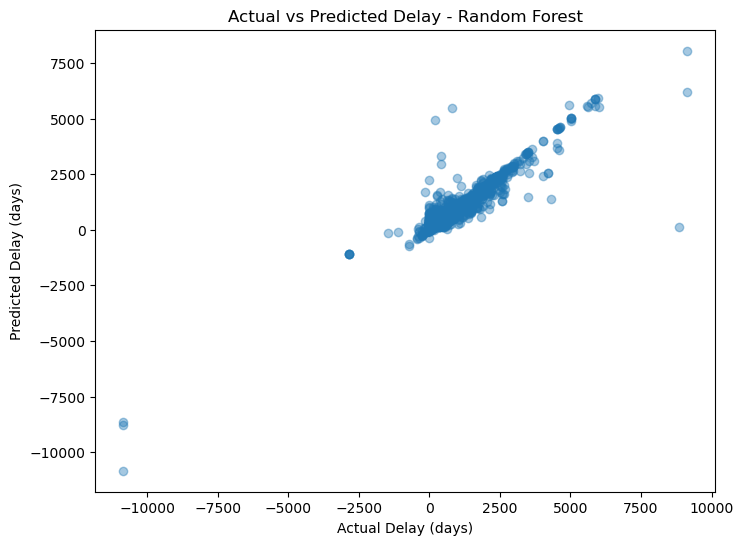

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.xlabel("Actual Delay (days)")
plt.ylabel("Predicted Delay (days)")
plt.title("Actual vs Predicted Delay - Random Forest")
plt.show()

In [72]:
import joblib

joblib.dump(rf_model, "../data/processed/random_forest_delay_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [73]:
import os

print(os.path.exists("../data/processed/merged_projects_cleaned.csv"))
print(os.path.exists("../data/processed/random_forest_delay_model.pkl"))

True
True
